# Planificador de Ruta — Sprint 10
### Tarea de Corzo: adaptar mapa + A* con punto de paso → lista de coordenadas en metros

**Cómo usar el día de la presentación:**
1. Reemplaza el cuerpo de `crear_mapa()` en la **Celda 2** con el que te den los JPAs
2. Actualiza `PUNTO_A`, `PUNTO_B`, `PUNTO_C` en la **Celda 3** con las coordenadas que te digan
3. Ejecuta todo → ingresa inicio y fin cuando se pida


In [ ]:
import json
import heapq
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
import shutil
import time
import random
import matplotlib.patches as patches

In [2]:
# ============================================================
# CELDA 2 — MAPA REAL
# El día de la presentación, reemplaza TODO el cuerpo de
# crear_mapa() con el que te entreguen los JPAs.
# NO cambies el nombre de la función ni el parámetro mostrar.
# ============================================================

def crear_mapa(mostrar=True):
    g = 3        # grosor pared
    c = 400      # tamaño de celda

    mapa = np.zeros((2800, 2800), dtype=np.uint8)

    # Bordes exteriores
    mapa[0:g, :] = 1
    mapa[-g:, :] = 1
    mapa[:, 0:g] = 1
    mapa[:, -g:] = 1

    # --- Paredes horizontales ---
    mapa[c*1:c*1+g, c*0:c*1] = 1
    mapa[c*1:c*1+g, c*2:c*3] = 1
    mapa[c*1:c*1+g, c*4:c*5] = 1
    mapa[c*2:c*2+g, c*1:c*2] = 1
    mapa[c*2:c*2+g, c*3:c*6] = 1
    mapa[c*3:c*3+g, c*0:c*1] = 1
    mapa[c*3:c*3+g, c*2:c*3] = 1
    mapa[c*3:c*3+g, c*4:c*5] = 1
    mapa[c*3:c*3+g, c*6:c*7] = 1
    mapa[c*4:c*4+g, c*1:c*4] = 1
    mapa[c*5:c*5+g, c*0:c*1] = 1
    mapa[c*5:c*5+g, c*2:c*3] = 1
    mapa[c*5:c*5+g, c*5:c*6] = 1
    mapa[c*6:c*6+g, c*3:c*4] = 1
    mapa[c*6:c*6+g, c*5:c*6] = 1

    # --- Paredes verticales ---
    mapa[c*3:c*4, c*1:c*1+g] = 1
    mapa[c*6:c*7, c*1:c*1+g] = 1
    mapa[c*2:c*3, c*2:c*2+g] = 1
    mapa[c*4:c*5, c*2:c*2+g] = 1
    mapa[c*1:c*2, c*3:c*3+g] = 1
    mapa[c*6:c*7, c*3:c*3+g] = 1
    mapa[c*0:c*1, c*4:c*4+g] = 1
    mapa[c*2:c*3, c*4:c*4+g] = 1
    mapa[c*4:c*5, c*4:c*4+g] = 1
    mapa[c*4:c*5, c*5:c*5+g] = 1
    mapa[c*1:c*2, c*6:c*6+g] = 1
    mapa[c*3:c*4, c*6:c*6+g] = 1
    mapa[c*5:c*6, c*6:c*6+g] = 1

    if mostrar:
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.imshow(mapa, cmap='Greys', origin='upper')
        ax.set_title("Mapa RIA 2026-1")
        ax.set_xlabel("X (píxeles)")
        ax.set_ylabel("Y (píxeles)")
        H, W = mapa.shape
        ax.set_xlim(0, W); ax.set_ylim(H, 0)
        ax.xaxis.set_major_locator(MultipleLocator(400))
        ax.yaxis.set_major_locator(MultipleLocator(400))
        ax.set_aspect('equal')
        ax.grid(True, which='major', linewidth=0.5, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return mapa


In [4]:
# ============================================================
# CELDA 3 — PUNTOS DE PASO A, B, C
# El día de la presentación, los JPAs te dirán qué coordenada
# de celda (X, Y) corresponde a cada punto.
# Formato: celda_a_pixel(X_celda, Y_celda)
# ============================================================

CELL_PX  = 400   # píxeles por celda (NO cambiar)
PASO     = 200   # paso del A* = mitad de celda (NO cambiar)
TAM_ROBOT = (200, 200)  # tamaño robot en píxeles (NO cambiar)

def celda_a_pixel(x_celda, y_celda):
    """Convierte índice de celda (X,Y) al centro en píxeles (fila, col).
    En la cuadrícula: X = columna, Y = fila (desde arriba)."""
    fila = 200 + CELL_PX * y_celda
    col  = 200 + CELL_PX * x_celda
    return (fila, col)

def pixel_a_metros(fila, col):
    """Convierte coordenada en píxeles a metros. Devuelve [x_m, y_m]."""
    x_m = round((col - 200) / 1000, 4)
    y_m = round((fila - 200) / 1000, 4)
    return [x_m, y_m]

# --- PUNTOS A, B, C: actualiza estas coordenadas de celda el día del reto ---
#  (las que están acá son las del notebook de ejemplo de los profes)
PUNTO_A = celda_a_pixel(0, 2)   # X=0, Y=2
PUNTO_B = celda_a_pixel(3, 1)   # X=3, Y=1
PUNTO_C = celda_a_pixel(0, 3)   # X=0, Y=3

WAYPOINTS = {'A': PUNTO_A, 'B': PUNTO_B, 'C': PUNTO_C}
print("Puntos de paso cargados:")
for k, v in WAYPOINTS.items():
    xm, ym = pixel_a_metros(*v)
    print(f"  {k}: pixel{v}  →  [{xm}, {ym}] m")


Puntos de paso cargados:
  A: pixel(1000, 200)  →  [0.0, 0.8] m
  B: pixel(600, 1400)  →  [1.2, 0.4] m
  C: pixel(1400, 200)  →  [0.0, 1.2] m


In [5]:
# ============================================================
# CELDA 4 — ALGORITMO A* (no modificar)
# ============================================================

class Nodo:
    def __init__(self, posicion, padre=None):
        self.posicion = posicion
        self.padre    = padre
        self.g = float('inf')
        self.h = float('inf')
        self.f = float('inf')
    def __eq__(self, o): return self.posicion == o.posicion
    def __lt__(self, o): return self.f < o.f

def heuristica(pos, obj):
    return np.sqrt((pos[0]-obj[0])**2 + (pos[1]-obj[1])**2)

def es_colision(mapa, x, y, tam):
    ancho, alto = tam
    if x <= 0 or x + ancho > mapa.shape[0] or y <= 0 or y + alto > mapa.shape[1]:
        return True
    h = int(ancho / 2)
    for i in range(h):
        for j in range(h):
            if mapa[x+i, y+j] != 0 or mapa[x-i, y-j] != 0:
                return True
    return False

def obtener_camino(nodo):
    camino, actual = [], nodo
    while actual:
        camino.append(actual.posicion)
        actual = actual.padre
    return camino[::-1]

def A_estrella(mapa, inicio, objetivo, tam_robot=TAM_ROBOT, paso=PASO):
    nodos_abiertos  = []
    nodos_cerrados  = set()
    costos = {inicio: 0}

    n0 = Nodo(inicio)
    n0.g = 0
    n0.h = heuristica(inicio, objetivo)
    n0.f = n0.h
    heapq.heappush(nodos_abiertos, n0)

    n_obj = Nodo(objetivo)

    while nodos_abiertos:
        actual = heapq.heappop(nodos_abiertos)
        nodos_cerrados.add(actual.posicion)

        if actual == n_obj:
            return obtener_camino(actual)

        x, y = actual.posicion
        for sx, sy in [(x-paso,y),(x+paso,y),(x,y-paso),(x,y+paso)]:
            if not es_colision(mapa, sx, sy, tam_robot):
                nuevo_costo = actual.g + 1
                if (sx,sy) not in nodos_cerrados:
                    if (sx,sy) not in costos or nuevo_costo < costos[(sx,sy)]:
                        costos[(sx,sy)] = nuevo_costo
                        nn = Nodo((sx,sy), actual)
                        nn.g = nuevo_costo
                        nn.h = heuristica((sx,sy), objetivo)
                        nn.f = nn.g + nn.h
                        heapq.heappush(nodos_abiertos, nn)
    return None


In [7]:
# ============================================================
# CELDA 5 — PLANIFICADOR CON PUNTO DE PASO
# ============================================================

def planificar_ruta_con_paso(mapa, inicio_px, waypoint_px, fin_px):
    """
    Corre A* dos veces:  inicio → waypoint → fin
    Devuelve la ruta completa como lista de [x_m, y_m] en metros.
    """
    print(f"\n▶ Tramo 1: {inicio_px} → {waypoint_px}")
    tramo1 = A_estrella(mapa, inicio_px, waypoint_px)
    if tramo1 is None:
        print("  ✗ No se encontró ruta al waypoint")
        return None

    print(f"  ✓ {len(tramo1)} puntos")
    print(f"▶ Tramo 2: {waypoint_px} → {fin_px}")
    tramo2 = A_estrella(mapa, waypoint_px, fin_px)
    if tramo2 is None:
        print("  ✗ No se encontró ruta al objetivo")
        return None

    print(f"  ✓ {len(tramo2)} puntos")

    # Unir: el waypoint no se duplica
    ruta_px = tramo1 + tramo2[1:]

    # Convertir a metros
    ruta_metros = [pixel_a_metros(fila, col) for fila, col in ruta_px]
    return ruta_px, ruta_metros


def visualizar_ruta(mapa, ruta_px, inicio_px, waypoint_px, fin_px, waypoint_nombre):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(mapa, cmap='Greys', origin='upper')
    ax.set_title(f"Ruta A* con waypoint {waypoint_nombre}", fontsize=13)

    H, W = mapa.shape
    ax.set_xlim(0, W); ax.set_ylim(H, 0)
    ax.xaxis.set_major_locator(MultipleLocator(CELL_PX))
    ax.yaxis.set_major_locator(MultipleLocator(CELL_PX))
    ax.set_aspect('equal')
    ax.grid(True, which='major', linewidth=0.5, alpha=0.3)

    filas, cols = zip(*ruta_px)
    ax.plot(cols, filas, 'b-o', markersize=5, linewidth=1.5, label='Ruta')

    ax.plot(inicio_px[1],    inicio_px[0],    'gs', markersize=14, label='Inicio',   zorder=5)
    ax.plot(waypoint_px[1],  waypoint_px[0],  'r^', markersize=14, label=f'Waypoint {waypoint_nombre}', zorder=5)
    ax.plot(fin_px[1],       fin_px[0],       'm*', markersize=16, label='Fin',      zorder=5)

    ax.legend(fontsize=9)
    ax.set_xlabel("X (píxeles)")
    ax.set_ylabel("Y (píxeles)")
    plt.tight_layout()
    plt.show()


### Celda 6 `input()` punto final e inicial 
Solo úsala si prefieres ingresar los valores manualmente cada vez. Ya limpia paréntesis y espacios para que no falle.

In [ ]:
# ============================================================
# CELDA 6 (OPCIONAL) — VERSIÓN CON input() ROBUSTA
# Úsala en vez de la Celda 6 SOLO si prefieres escribir los
# valores cada vez que corres el notebook (más lento en VS Code,
# pero más flexible). Esta versión limpia paréntesis, espacios
# y comillas para que no truene si escribes "(0,0)" o "0, 0".
# ============================================================

def limpiar_par(texto):
    texto = texto.strip().replace('(', '').replace(')', '')
    texto = texto.replace(' ', '')
    return [int(v) for v in texto.split(',')]

entrada_inicio = input("Ingresa punto de INICIO, formato X,Y (ej: 0,0): ")
entrada_fin    = input("Ingresa punto FINAL,  formato X,Y (ej: 6,6): ")
entrada_clase  = input("Clase detectada por IA (A / B / C): ")

xi, yi = limpiar_par(entrada_inicio)
xf, yf = limpiar_par(entrada_fin)




# Detección por cámara

###  Funciones de perdida y carga de modelos

In [ ]:
# ── 1. FUNCIONES DE PÉRDIDA modelo 1──────────────────────────────

def iou_metric(y_true, y_pred):
    """Métrica IoU para monitorear en TensorBoard (no diferenciable, solo lectura)."""
    x1g, y1g, x2g, y2g = tf.unstack(y_true, axis=-1)
    x1p, y1p, x2p, y2p = tf.unstack(y_pred, axis=-1)
    xi1 = tf.maximum(x1g, x1p);  yi1 = tf.maximum(y1g, y1p)
    xi2 = tf.minimum(x2g, x2p);  yi2 = tf.minimum(y2g, y2p)
    inter = tf.maximum(xi2 - xi1, 0.0) * tf.maximum(yi2 - yi1, 0.0)
    area_g = tf.maximum((x2g - x1g) * (y2g - y1g), 0.0)
    area_p = tf.maximum((x2p - x1p) * (y2p - y1p), 0.0)
    union  = area_g + area_p - inter + 1e-7
    return tf.reduce_mean(inter / union)


def giou_loss(y_true, y_pred):
    """
    GIoU con protección contra coordenadas invertidas.
    Las predicciones se ordenan (x1<x2, y1<y2) antes de calcular.
    """
    # --- Garantizar x1<x2, y1<y2 en predicciones ---
    x1p_raw, y1p_raw, x2p_raw, y2p_raw = tf.unstack(y_pred, axis=-1)
    x1p = tf.minimum(x1p_raw, x2p_raw)
    y1p = tf.minimum(y1p_raw, y2p_raw)
    x2p = tf.maximum(x1p_raw, x2p_raw)
    y2p = tf.maximum(y1p_raw, y2p_raw)

    x1g, y1g, x2g, y2g = tf.unstack(y_true, axis=-1)

    # Intersección
    xi1 = tf.maximum(x1g, x1p);  yi1 = tf.maximum(y1g, y1p)
    xi2 = tf.minimum(x2g, x2p);  yi2 = tf.minimum(y2g, y2p)
    inter = tf.maximum(xi2 - xi1, 0.0) * tf.maximum(yi2 - yi1, 0.0)

    area_g = (x2g - x1g) * (y2g - y1g)
    area_p = (x2p - x1p) * (y2p - y1p)
    union  = area_g + area_p - inter + 1e-7
    iou    = inter / union

    # Caja envolvente (penalización GIoU)
    xc1 = tf.minimum(x1g, x1p);  yc1 = tf.minimum(y1g, y1p)
    xc2 = tf.maximum(x2g, x2p);  yc2 = tf.maximum(y2g, y2p)
    area_c = (xc2 - xc1) * (yc2 - yc1) + 1e-7

    giou = iou - (area_c - union) / area_c
    return tf.reduce_mean(1.0 - giou)


def mse_loss(y_true, y_pred):
    """MSE puro como etapa de calentamiento."""
    return tf.reduce_mean(tf.square(y_true - y_pred))


def bbox_combined_loss(y_true, y_pred):
    """
    MSE + GIoU con peso equilibrado.
    MSE da gradientes suaves desde el inicio;
    GIoU refina la superposición espacial.
    """
    return mse_loss(y_true, y_pred) + giou_loss(y_true, y_pred)


# ── 1. FUNCIONES DE PÉRDIDA modelo 2──────────────────────────────

def iou_metric_2(y_true, y_pred):
    """Métrica IoU para monitorear en TensorBoard (no diferenciable, solo lectura)."""
    x1g, y1g, x2g, y2g = tf.unstack(y_true, axis=-1)
    x1p, y1p, x2p, y2p = tf.unstack(y_pred, axis=-1)
    xi1 = tf.maximum(x1g, x1p);  yi1 = tf.maximum(y1g, y1p)
    xi2 = tf.minimum(x2g, x2p);  yi2 = tf.minimum(y2g, y2p)
    inter = tf.maximum(xi2 - xi1, 0.0) * tf.maximum(yi2 - yi1, 0.0)
    area_g = tf.maximum((x2g - x1g) * (y2g - y1g), 0.0)
    area_p = tf.maximum((x2p - x1p) * (y2p - y1p), 0.0)
    union  = area_g + area_p - inter + 1e-7
    return tf.reduce_mean(inter / union)


def giou_loss_2(y_true, y_pred):
    """
    GIoU con protección contra coordenadas invertidas.
    Las predicciones se ordenan (x1<x2, y1<y2) antes de calcular.
    """
    # --- Garantizar x1<x2, y1<y2 en predicciones ---
    x1p_raw, y1p_raw, x2p_raw, y2p_raw = tf.unstack(y_pred, axis=-1)
    x1p = tf.minimum(x1p_raw, x2p_raw)
    y1p = tf.minimum(y1p_raw, y2p_raw)
    x2p = tf.maximum(x1p_raw, x2p_raw)
    y2p = tf.maximum(y1p_raw, y2p_raw)

    x1g, y1g, x2g, y2g = tf.unstack(y_true, axis=-1)

    # Intersección
    xi1 = tf.maximum(x1g, x1p);  yi1 = tf.maximum(y1g, y1p)
    xi2 = tf.minimum(x2g, x2p);  yi2 = tf.minimum(y2g, y2p)
    inter = tf.maximum(xi2 - xi1, 0.0) * tf.maximum(yi2 - yi1, 0.0)

    area_g = (x2g - x1g) * (y2g - y1g)
    area_p = (x2p - x1p) * (y2p - y1p)
    union  = area_g + area_p - inter + 1e-7
    iou    = inter / union

    # Caja envolvente (penalización GIoU)
    xc1 = tf.minimum(x1g, x1p);  yc1 = tf.minimum(y1g, y1p)
    xc2 = tf.maximum(x2g, x2p);  yc2 = tf.maximum(y2g, y2p)
    area_c = (xc2 - xc1) * (yc2 - yc1) + 1e-7

    giou = iou - (area_c - union) / area_c
    return tf.reduce_mean(1.0 - giou)


def mse_loss_2(y_true, y_pred):
    """MSE puro como etapa de calentamiento."""
    return tf.reduce_mean(tf.square(y_true - y_pred))


def bbox_combined_loss_2(y_true, y_pred):
    mse  = mse_loss_2(y_true, y_pred)
    giou = giou_loss_2(y_true, y_pred)

    # Penalizar si el área predicha es muy diferente al área real
    w_true = y_true[:, 2] - y_true[:, 0]
    h_true = y_true[:, 3] - y_true[:, 1]
    w_pred = y_pred[:, 2] - y_pred[:, 0]
    h_pred = y_pred[:, 3] - y_pred[:, 1]
    size_loss = tf.reduce_mean(tf.square(w_true - w_pred) + tf.square(h_true - h_pred))

    return mse + giou + 0.5 * size_loss



# ── 1. Cargar el modelo 1──────────────────────────────────
modelo1 = tf.keras.models.load_model(
    'mejor_modelo_mobilenet.keras',
    custom_objects={
        'bbox_combined_loss': bbox_combined_loss,
        'mse_loss': mse_loss,
        'giou_loss': giou_loss,
        'iou_metric': iou_metric
    }
)

# ── 1. Cargar el modelo 2 ──────────────────────────────────
modelo2 = tf.keras.models.load_model(
    'mejor_modelo_mobilenet_rotacion.keras',
    custom_objects={
        'bbox_combined_loss': bbox_combined_loss_2,
        'mse_loss': mse_loss_2,
        'giou_loss': giou_loss_2,
        'iou_metric': iou_metric_2
    }
)







### Deteccion por camara

In [ ]:
# ── Predicción combinada ─────────────────────────────────
def predict_combinado(input_batch):
    """
    Usa clasificación del modelo1 y bbox del modelo2.
    """
    _, class_pred  = modelo1.predict(input_batch, verbose=0)  # solo nos interesa la clase
    bbox_pred, _   = modelo2.predict(input_batch, verbose=0)  # solo nos interesa el bbox

    # Ordenar coordenadas
    x1 = np.minimum(bbox_pred[:, 0], bbox_pred[:, 2])
    y1 = np.minimum(bbox_pred[:, 1], bbox_pred[:, 3])
    x2 = np.maximum(bbox_pred[:, 0], bbox_pred[:, 2])
    y2 = np.maximum(bbox_pred[:, 1], bbox_pred[:, 3])
    bboxes = np.stack([x1, y1, x2, y2], axis=-1)

    clase     = CLASS_NAMES[np.argmax(class_pred[0])]
    confianza = np.max(class_pred[0])

    return bboxes[0], clase, confianza

In [ ]:
def real_time_detection(camera_index=0, confidence_threshold=0.8):
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print(f"No se pudo abrir la cámara con índice {camera_index}")
        return

    print("Presiona 'q' para salir de la detección en tiempo real")
    print("Iniciando detección...")

    prev_time = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            print("No se pudo leer el frame de la cámara")
            break

        original_h, original_w = frame.shape[:2]

        # Preprocesar
        img_resized = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        input_batch = np.expand_dims(img_resized / 255.0, axis=0)

        # ── Predicción combinada ─────────────────────────
        bbox, clase, confianza = predict_combinado(input_batch)

        if confianza >= confidence_threshold:
            x1 = int(bbox[0] * original_w)
            y1 = int(bbox[1] * original_h)
            x2 = int(bbox[2] * original_w)
            y2 = int(bbox[3] * original_h)

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{clase}: {confianza:.2f}", (x1, max(y1 - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # FPS
        curr_time = time.time()
        fps       = 1 / (curr_time - prev_time) if prev_time > 0 else 0
        prev_time = curr_time
        cv2.putText(frame, f"FPS: {fps:.1f}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

        cv2.imshow('Detección en Tiempo Real', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# Main

In [ ]:
#Codigo para detectar la clase:
#cambiio

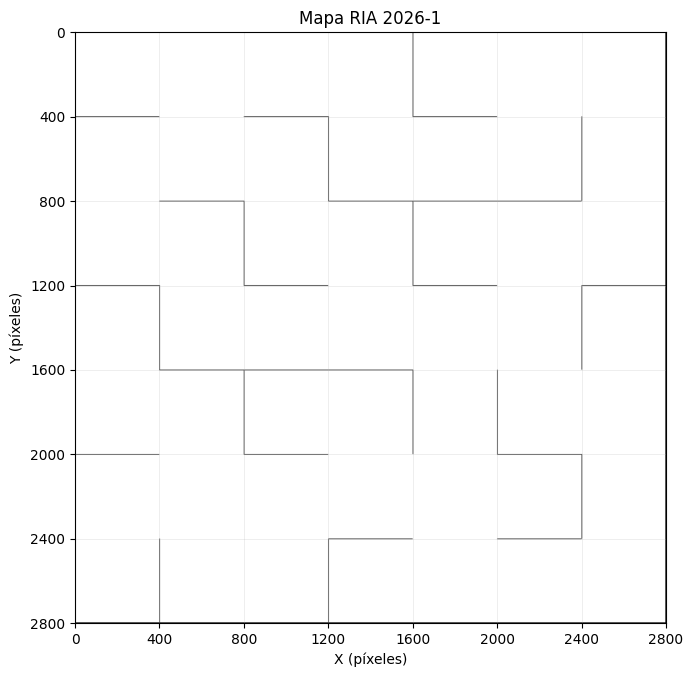


▶ Tramo 1: (200, 200) → (1000, 200)
  ✓ 9 puntos
▶ Tramo 2: (1000, 200) → (2600, 2600)
  ✓ 21 puntos


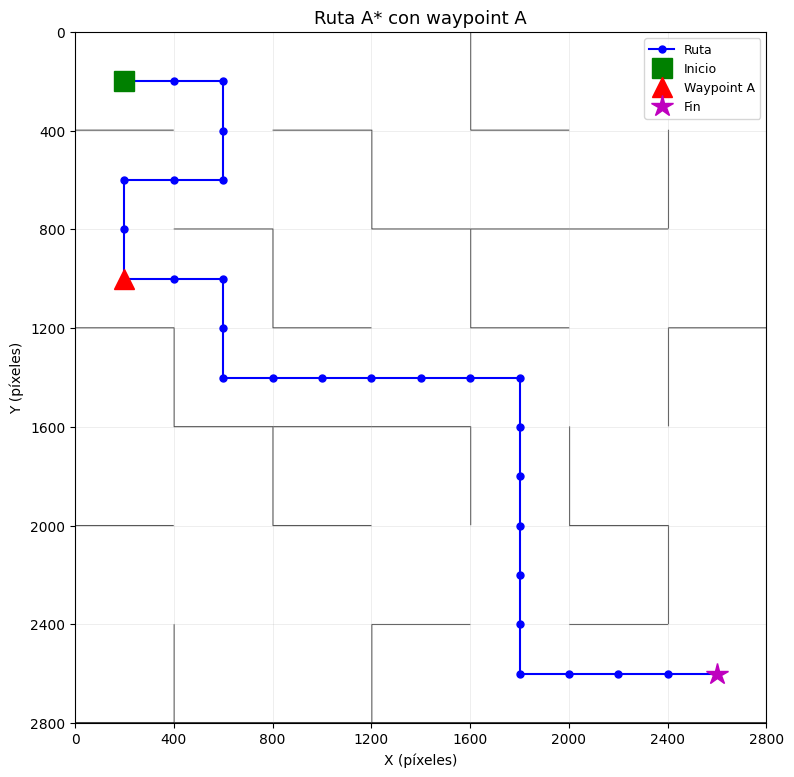


  RUTA EN METROS (para enviar al carrito)
Total de puntos: 29

Lista completa:
[[0.0, 0.0], [0.2, 0.0], [0.4, 0.0], [0.4, 0.2], [0.4, 0.4], [0.2, 0.4], [0.0, 0.4], [0.0, 0.6], [0.0, 0.8], [0.2, 0.8], [0.4, 0.8], [0.4, 1.0], [0.4, 1.2], [0.6, 1.2], [0.8, 1.2], [1.0, 1.2], [1.2, 1.2], [1.4, 1.2], [1.6, 1.2], [1.6, 1.4], [1.6, 1.6], [1.6, 1.8], [1.6, 2.0], [1.6, 2.2], [1.6, 2.4], [1.8, 2.4], [2.0, 2.4], [2.2, 2.4], [2.4, 2.4]]

Formato compacto:
[0.0, 0.0],[0.2, 0.0],[0.4, 0.0],[0.4, 0.2],[0.4, 0.4],[0.2, 0.4],[0.0, 0.4],[0.0, 0.6],[0.0, 0.8],[0.2, 0.8],[0.4, 0.8],[0.4, 1.0],[0.4, 1.2],[0.6, 1.2],[0.8, 1.2],[1.0, 1.2],[1.2, 1.2],[1.4, 1.2],[1.6, 1.2],[1.6, 1.4],[1.6, 1.6],[1.6, 1.8],[1.6, 2.0],[1.6, 2.2],[1.6, 2.4],[1.8, 2.4],[2.0, 2.4],[2.2, 2.4],[2.4, 2.4]

✓ Ruta guardada en ruta_generada.json


In [ ]:
# ============================================================
# CELDA 7 — EJECUCIÓN PRINCIPAL


clase_detectada = 'A'  # Resultado de la IA: 'A', 'B' o 'C'
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

# --- 1. Cargar mapa ---
mapa = crear_mapa(mostrar=True).astype(np.float64)

inicio_px = celda_a_pixel(xi, yi)
fin_px    = celda_a_pixel(xf, yf)

clase_detectada = clase_detectada.strip().upper()

if clase_detectada not in WAYPOINTS:
    print(f"Clase '{clase_detectada}' no válida. Debe ser A, B o C.")
else:
    waypoint_px = WAYPOINTS[clase_detectada]

    # --- 2. Planificar ---
    resultado = planificar_ruta_con_paso(mapa, inicio_px, waypoint_px, fin_px)

    if resultado:
        ruta_px, ruta_metros = resultado

        # --- 3. Visualizar ---
        visualizar_ruta(mapa, ruta_px, inicio_px, waypoint_px, fin_px, clase_detectada)

        # --- 4. Mostrar ruta en metros (lo que recibe Ccori) ---
        print("\n" + "="*55)
        print("  RUTA EN METROS (para enviar al carrito)")
        print("="*55)
        print(f"Total de puntos: {len(ruta_metros)}")
        print("\nLista completa:")
        print(ruta_metros)

        print("\nFormato compacto:")
        compacto = ",".join(str(p) for p in ruta_metros)
        print(compacto)

        # --- 5. Guardar como JSON para José (envío MQTT) ---
        with open('ruta_generada.json', 'w') as f:
            json.dump({'ruta': ruta_metros}, f)
        print("\n✓ Ruta guardada en ruta_generada.json")
    else:
        print("\n✗ No se pudo generar la ruta completa.")
